<a href="https://colab.research.google.com/github/matt-ritton/ts.ethanol-production/blob/main/ethanol-production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💻 About this notebook

This academic-oriented notebook was created to analyze historical series of ethanol production in the state of Minas Gerais - BR. The objective is to propose and justify a suitable model for ethanol production forecasts.

[ARRUMAR]
The data were obtained from the SIDRA system of the Brazilian Institute of Geography and Statistics (IBGE).

Data: https://sidra.ibge.gov.br/tabela/6588

### 💬 What will be discussed here?
The notebook is divided into sections based on a time series analysis to solve a production prediction problem. I tried to make it as didactic as possible for understanding.

In [26]:
# Necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings

In [2]:
# Dataset
!wget -O ETHANOL.csv https://raw.githubusercontent.com/matt-ritton/ts.ethanol-production/refs/heads/main/ETHANOL.csv

--2026-06-03 23:24:07--  https://raw.githubusercontent.com/matt-ritton/ts.ethanol-production/refs/heads/main/ETHANOL.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2996 (2.9K) [text/plain]
Saving to: ‘ETHANOL.csv’

ETHANOL.csv         100%[===================>]   2.93K  --.-KB/s    in 0s      

2026-06-03 23:24:08 (37.0 MB/s) - ‘ETHANOL.csv’ saved [2996/2996]



In [3]:
# ------------------------------------------------------------
# Plot Styles
# ------------------------------------------------------------

# Seaborn Theme
sns.set_theme(style="whitegrid", context="notebook")

title_style = {"fontweight": "semibold","pad": 12}
label_style = {"fontsize": 10,"fontweight": "semibold", "labelpad": 12}
tick_style = {"labelsize": 9, "labelcolor": "#606060"}
grid_style = {"linestyle": "-", "linewidth": 0.7, "alpha": 0.35}

In [4]:
# ------------------------------------------------------------
# Data preparation
# ------------------------------------------------------------

df = pd.read_csv('ETHANOL.csv', parse_dates=['Date'])

# Set the date as the dataset index
df = df.set_index('Date').sort_index()
df.index.freq = 'MS'

serie = df['Production'].astype(float)

# Drop 2026 months
serie = serie[serie.index <= '2025-12-01']

# ------------------------------------------------------------
# Train-test split
# ------------------------------------------------------------

forecast_horizon = 12

train = serie.iloc[:-forecast_horizon]
test = serie.iloc[-forecast_horizon:]

print("Minas Gerais Ethanol Production")
print(f"Full series : {serie.index.min():%Y-%m} to {serie.index.max():%Y-%m} ({len(serie)} obs)")
print(f"Training    : {train.index.min():%Y-%m} to {train.index.max():%Y-%m} ({len(train)} obs)")
print(f"Testing     : {test.index.min():%Y-%m} to {test.index.max():%Y-%m} ({len(test)} obs)")

Minas Gerais Ethanol Production
Full series : 2012-01 to 2025-12 (168 obs)
Training    : 2012-01 to 2024-12 (156 obs)
Testing     : 2025-01 to 2025-12 (12 obs)


# 🔍 Exploratory Time Series Analysis

Lorem Ipsum

In [5]:
# ------------------------------------------------------------
# Time Series Info
# ------------------------------------------------------------

print(f"Minas Gerais Ethanol Production")
print(f"Initial date: {serie.index.min().strftime('%Y-%m')}")
print(f"Final date: {serie.index.max().strftime('%Y-%m')}")
print(f"Number of observations: {serie.shape[0]}")
print(f"Number of missing values: {serie.isna().sum()}")

Minas Gerais Ethanol Production
Initial date: 2012-01
Final date: 2025-12
Number of observations: 168
Number of missing values: 0


In [6]:
# ------------------------------------------------------------
# Descriptive Statistics (training set)
# ------------------------------------------------------------

summary_statistics = pd.DataFrame({
    "Mean": [train.mean()],
    "Median": [train.median()],
    "Standard deviation": [train.std()],
    "Minimum": [train.min()],
    "Maximum": [train.max()],
    "Missing values": [train.isna().sum()]
})

summary_statistics

,Mean,Median,Standard deviation,Minimum,Maximum,Missing values
0,247273.551282,257776.5,189237.761291,0.0,574332.0,0


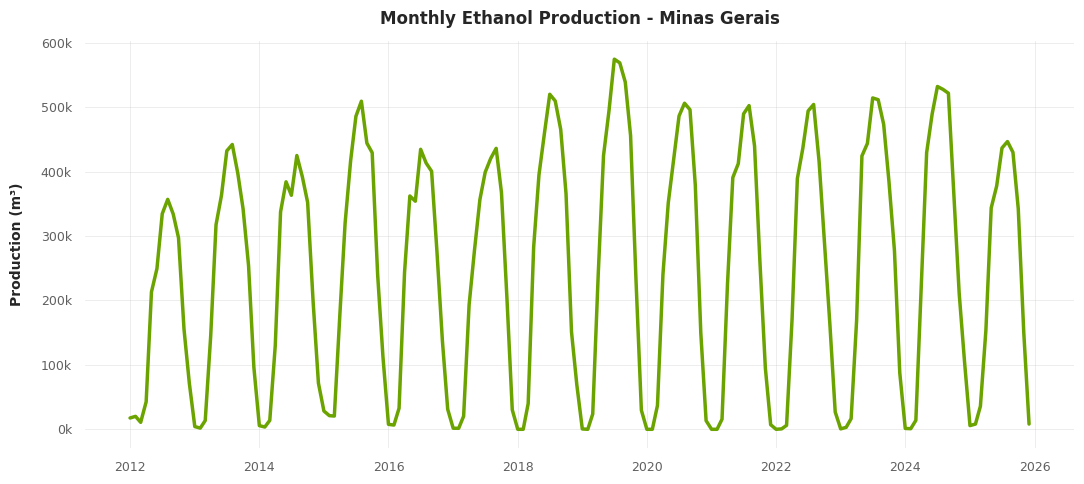

In [7]:
# ------------------------------------------------------------
# Time Series Visualization (Complete)
# ------------------------------------------------------------

# Plotting
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(x=serie.index, y=serie.values, ax=ax, linewidth=2.5, color="#6BA300")

## Title
ax.set_title(f"Monthly Ethanol Production - Minas Gerais", **title_style)

## Axes Labels
ax.set_xlabel("")
ax.set_ylabel("Production (m³)", **label_style)

## Axes ticks
ax.tick_params(axis='both', which="both", **tick_style)

## Y axis formatter
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

## Hide unnecessary edges
for spine in ax.spines.values():
    spine.set_visible(False)

## Grid
ax.grid( True, which="major", **grid_style)

plt.tight_layout()
plt.show()

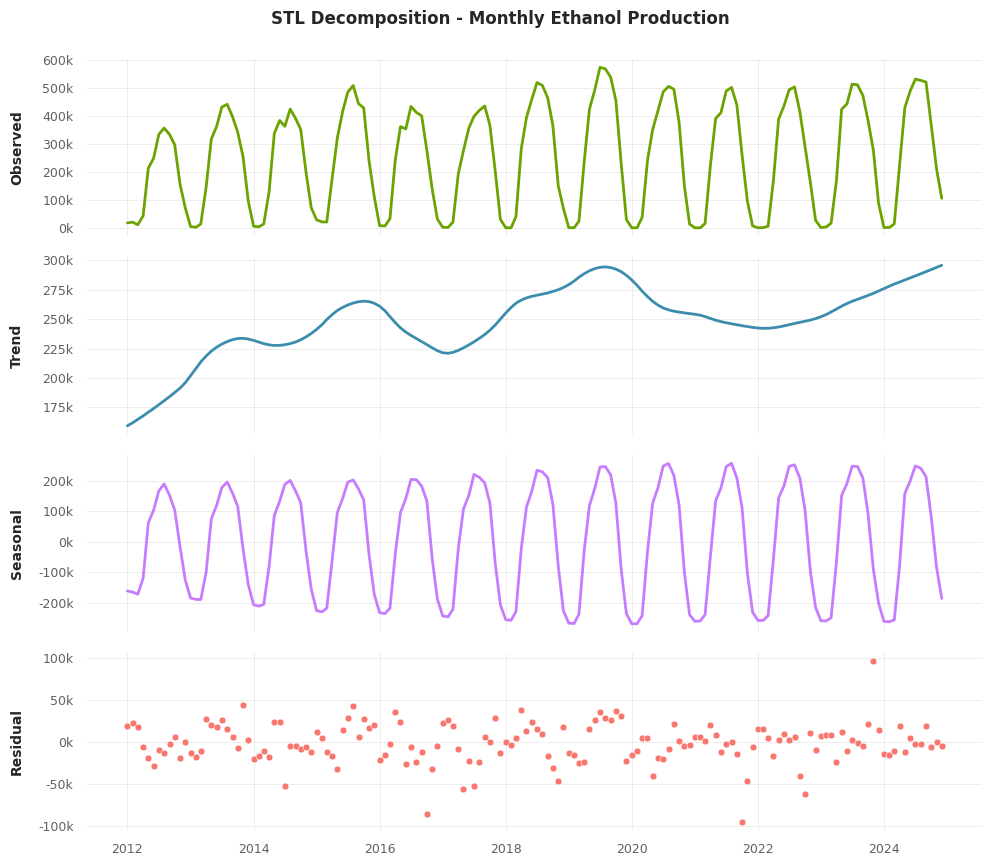

In [8]:
# ------------------------------------------------------------
# Time Series Decomposition (training set)
# ------------------------------------------------------------
stl = STL(train, period=12, robust=True)
res = stl.fit()

# Plotting decomposition
observed = train
trend = res.trend
seasonal = res.seasonal
residual = res.resid

fig, axes = plt.subplots(4, 1,figsize=(10, 9),sharex=True)

component_data = [
    (observed, "Observed", "#6BA300"),
    (trend, "Trend", "#3C8DAD"),
    (seasonal, "Seasonal", "#C77CFF"),
    (residual, "Residual", "#F8766D")
]

for ax, (series, label, color) in zip(axes, component_data):

    if label == "Residual":
      sns.scatterplot(x=series.index, y=series.values, ax=ax, color=color, s=24)
    else:
      sns.lineplot(x=series.index, y=series.values, ax=ax, linewidth=2.0, color=color)

    fig.suptitle(f"STL Decomposition - Monthly Ethanol Production", fontsize=12, fontweight="semibold", y=0.96)

    ax.set_ylabel(label, **label_style)
    ax.yaxis.set_label_coords(-0.07, 0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

    ax.grid(True, which="major", **grid_style)

    ax.tick_params(axis='both', which="both", **tick_style)

    for spine in ax.spines.values():
          spine.set_visible(False)

## Hide X axis label in upper panels
for ax in axes[:-1]:
    ax.set_xlabel("")

axes[-1].set_xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## ♻ Seasonal Behavior

Lorem Ipsum

In [9]:
# Seasonal serie
seasonal_df = train.to_frame(name="Production")
seasonal_df["Month"] = seasonal_df.index.month
seasonal_df["Year"] = seasonal_df.index.year

# Seasonal serie (Last X available years)
last_n_years = 7
recent_years = sorted(seasonal_df["Year"].unique())[-last_n_years:]
recent_seasonal_df = seasonal_df[seasonal_df["Year"].isin(recent_years)].copy()

# Labels for monthly charts
month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

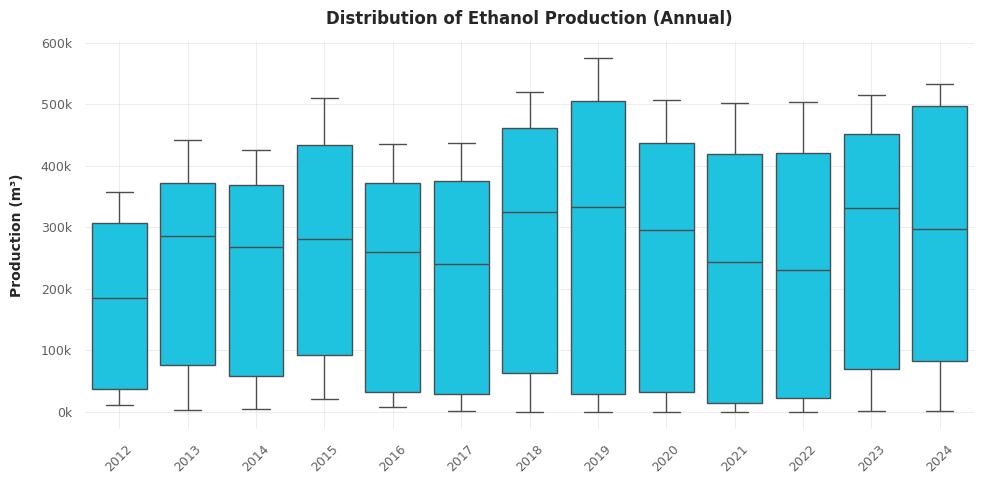

In [10]:
# ------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=seasonal_df, x="Year", y="Production", ax=ax, color="#00D9FF")

ax.set_title(f"Distribution of Ethanol Production (Annual)", **title_style)

ax.set_xlabel("")
ax.set_ylabel("Production (m³)", **label_style)

ax.tick_params(axis="x", which="both", **tick_style, rotation=45)
ax.tick_params(axis="y", which="both", **tick_style)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

for spine in ax.spines.values():
      spine.set_visible(False)

ax.grid(True, which="major", **grid_style)

plt.tight_layout()
plt.show()

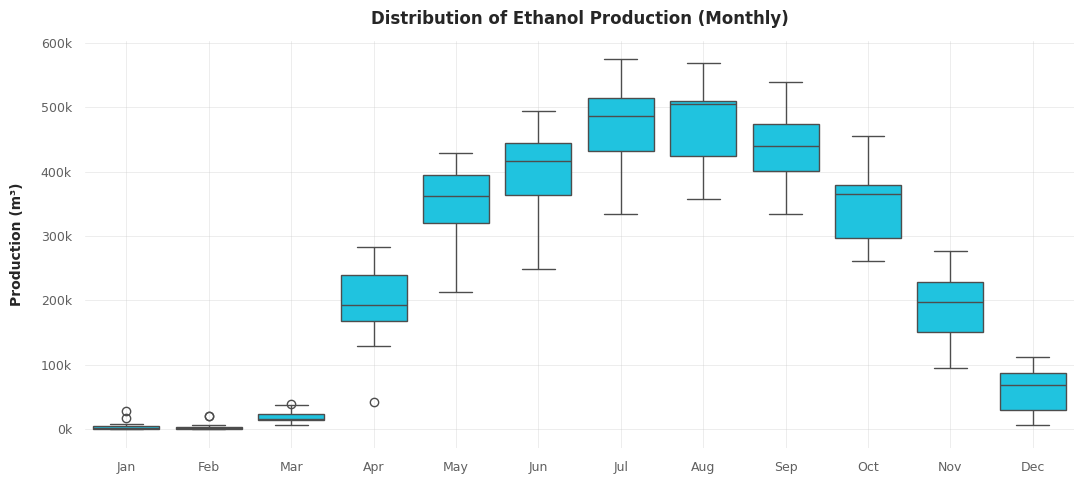

In [11]:
# ------------------------------------------------------------
# Monthly Boxplot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(data=seasonal_df, x="Month", y="Production", ax=ax, color="#00D9FF")

ax.set_title(f"Distribution of Ethanol Production (Monthly)", **title_style)

ax.set_xlabel("", **label_style)
ax.set_ylabel("Production (m³)", **label_style)

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)

ax.tick_params(axis='both', which="both", **tick_style)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

for spine in ax.spines.values():
      spine.set_visible(False)

ax.grid(True, which="major", **grid_style)

plt.tight_layout()
plt.show()

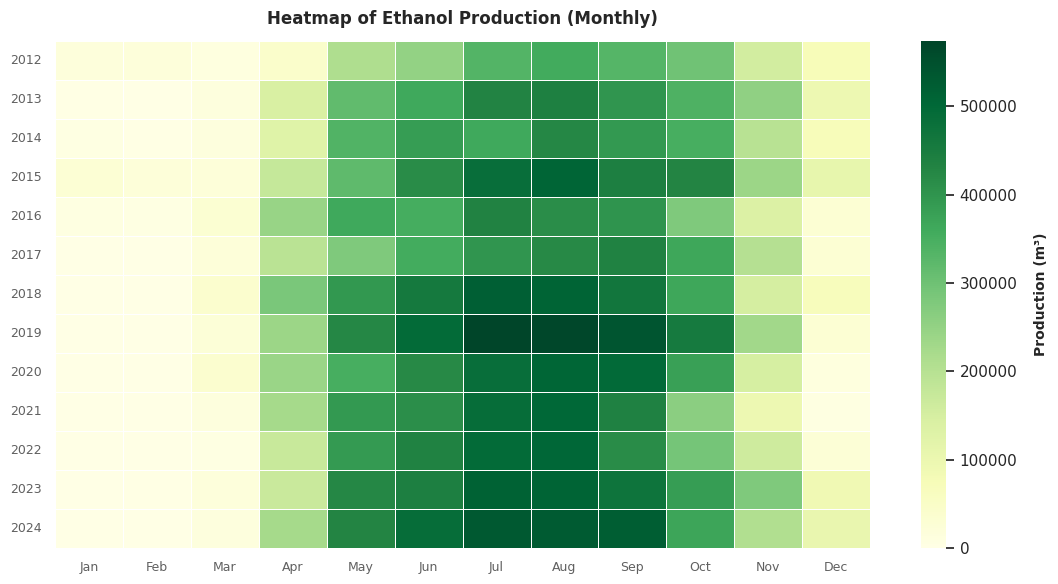

In [12]:
# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

heatmap_data = seasonal_df.pivot_table(index="Year", columns="Month", values="Production")

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(heatmap_data, cmap="YlGn", linewidths=0.5, linecolor="white", cbar_kws={"label": "Production (m³)"},ax=ax)
cbar = ax.figure.axes[-1]
cbar.set_ylabel("Production (m³)", **label_style)

ax.set_title(f"Heatmap of Ethanol Production (Monthly)", **title_style)

ax.set_xlabel("", **label_style)
ax.set_ylabel("", **label_style)

ax.set_xticklabels(month_labels, rotation=0)

ax.tick_params(axis='both', which="both", **tick_style)

ax.grid(True, which="major", **grid_style)

plt.tight_layout()
plt.show()

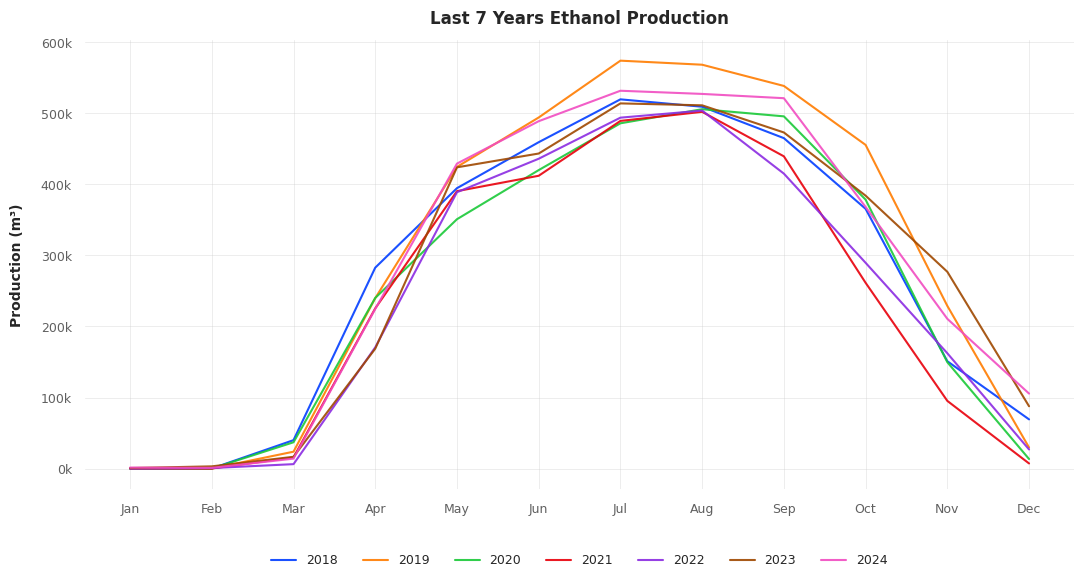

In [13]:
# ------------------------------------------------------------
# Seasonal subseries plot (Last 7 years)
# ------------------------------------------------------------

years = sorted(seasonal_df["Year"].unique())
palette = sns.color_palette("bright", n_colors=len(years))

fig, ax = plt.subplots(figsize=(11, 6))

for color, (year, group) in zip(palette, recent_seasonal_df.groupby("Year")):
    sns.lineplot(x=group["Month"], y=group["Production"], ax=ax, linewidth=1.5, alpha=0.9, label=year, color=color)

ax.set_title(f"Last {last_n_years} Years Ethanol Production", **title_style)

ax.set_xlabel("", **label_style)
ax.set_ylabel("Production (m³)", **label_style)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)

ax.tick_params(axis='both', which="both", **tick_style)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

for spine in ax.spines.values():
      spine.set_visible(False)

ax.grid(True, which="major", **grid_style)

ax.legend(bbox_to_anchor=(0.5, -0.12), loc="upper center", ncol=last_n_years, frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

### Seasonal Behavior Analysis

Lorem Ipsum

# 📈 Stationarity Analysis

Lorem ipsum

In [14]:
# ------------------------------------------------------------
# Augmented Dickey-Fuller Test
# ------------------------------------------------------------
adf_result = adfuller(train.dropna())

adf_output = pd.Series(
    {
        "ADF statistic": adf_result[0],
        "p-value": adf_result[1],
        "Number of lags used": adf_result[2],
        "Number of observations": adf_result[3],
        "Critical value 1%": adf_result[4]["1%"],
        "Critical value 5%": adf_result[4]["5%"],
        "Critical value 10%": adf_result[4]["10%"]
    }
)

adf_output

,0
ADF statistic,-2.775145
p-value,0.061913
Number of lags used,12.000000
Number of observations,143.000000
Critical value 1%,-3.476927
Critical value 5%,-2.881973
Critical value 10%,-2.577665


In [15]:
alpha = 0.05

if adf_result[1] <= alpha:
    print("Reject H0: the series is likely stationary according to the ADF test.")
else:
    print("Fail to reject H0: the series is likely non-stationary according to the ADF test.")

Fail to reject H0: the series is likely non-stationary according to the ADF test.


In [16]:
# ------------------------------------------------------------
# KPSS test
# ------------------------------------------------------------

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpss_result = kpss(
        train.dropna(),
        regression="c",
        nlags="auto"
    )

kpss_output = pd.Series(
    {
        "KPSS statistic": kpss_result[0],
        "p-value": kpss_result[1],
        "Number of lags used": kpss_result[2],
        "Critical value 10%": kpss_result[3]["10%"],
        "Critical value 5%": kpss_result[3]["5%"],
        "Critical value 2.5%": kpss_result[3]["2.5%"],
        "Critical value 1%": kpss_result[3]["1%"]
    }
)

kpss_output

,0
KPSS statistic,0.142333
p-value,0.100000
Number of lags used,6.000000
Critical value 10%,0.347000
Critical value 5%,0.463000
Critical value 2.5%,0.574000
Critical value 1%,0.739000


In [17]:
alpha = 0.05

if kpss_result[1] <= alpha:
    print("Reject H0: the series is likely non-stationary according to the KPSS test.")
else:
    print("Fail to reject H0: the series is likely stationary according to the KPSS test.")

Fail to reject H0: the series is likely stationary according to the KPSS test.


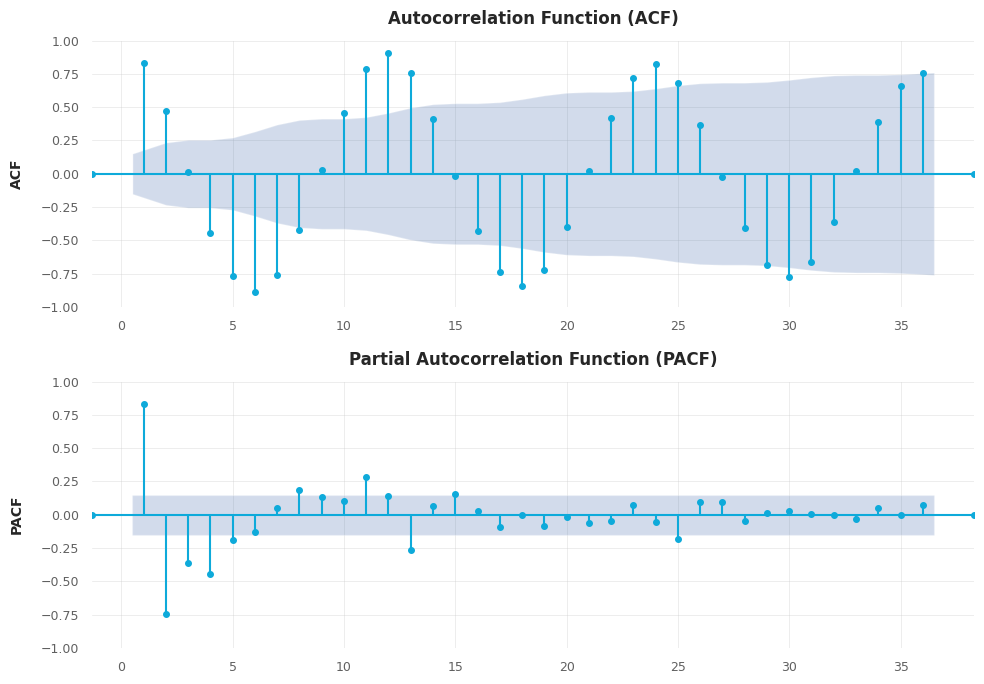

In [18]:
# ------------------------------------------------------------
# Plot ACF and PACF
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

plot_acf(serie, lags=36, ax=axes[0], alpha=0.05, zero=False, title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})
plot_pacf(serie, lags=36, ax=axes[1], alpha=0.05, zero=False, method="ywm", title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})

axes[0].set_title("Autocorrelation Function (ACF)", **title_style)
axes[0].set_ylabel("ACF", **label_style)

axes[1].set_title("Partial Autocorrelation Function (PACF)", **title_style)
axes[1].set_ylabel("PACF", **label_style)

for ax in axes:
    ax.tick_params(axis='both', which="both", **tick_style)

    ax.grid(True, which="major", **grid_style)

    for spine in ax.spines.values():
      spine.set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
# Seasonal difference (D=1, s=12)
seasonal_diff = train.diff(12).dropna()

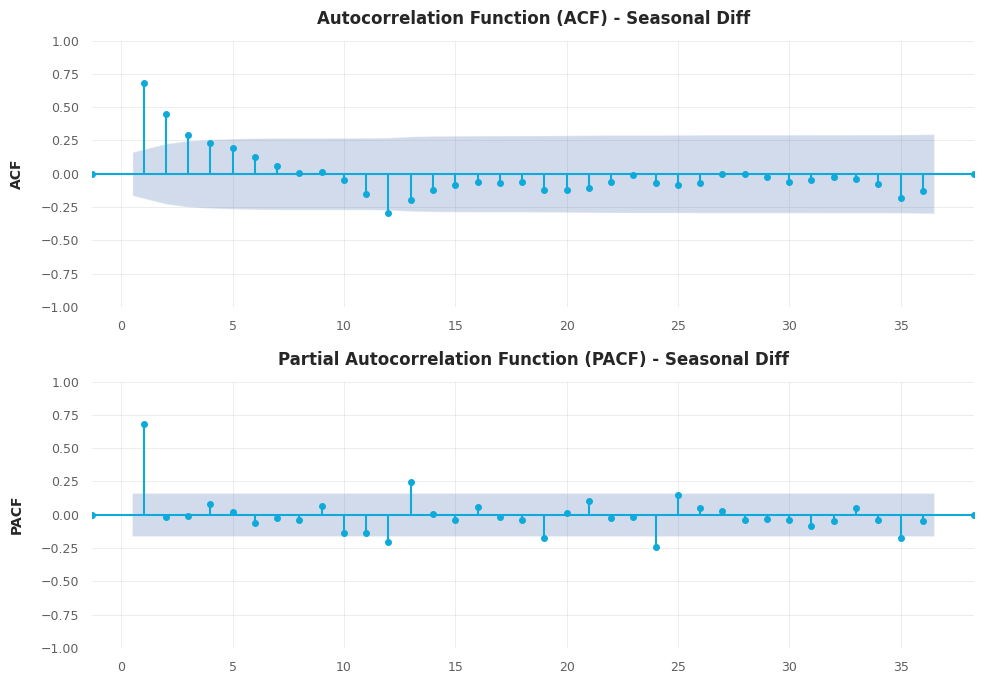

In [20]:
# ------------------------------------------------------------
# Plot ACF and PACF (Seasonally Differenced)
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

plot_acf(seasonal_diff, lags=36, ax=axes[0], alpha=0.05, zero=False, title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})
plot_pacf(seasonal_diff, lags=36, ax=axes[1], alpha=0.05, zero=False, method="ywm", title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})

axes[0].set_title("Autocorrelation Function (ACF) - Seasonal Diff", **title_style)
axes[0].set_ylabel("ACF", **label_style)

axes[1].set_title("Partial Autocorrelation Function (PACF) - Seasonal Diff", **title_style)
axes[1].set_ylabel("PACF", **label_style)

for ax in axes:
    ax.tick_params(axis='both', which="both", **tick_style)

    ax.grid(True, which="major", **grid_style)

    for spine in ax.spines.values():
      spine.set_visible(False)

plt.tight_layout()
plt.show()

### Autocorrelation and Partial Autocorrelation Analysis (after Seasonal Difference)

Using the ADF and KPSS tests, it was confirmed that the series is stationary in level (d = 0), but a seasonal difference was still necessary (D = 1)

After seasonal difference, we can make a clean analysis:

*   **Non-seasonal lags**: ACF decays geometrically and PACF cuts off abruptly after lag 1, suggesting AR(1): p=1, q= 0.

*   **Seasonal lags**: ACF has a single significant negative peak at 12, which is not repeated at 24 or 36, suggesting seasonal MA(2): P=0, Q=2.

Given the observed characteristics, we have a possible candidate model: $SARIMA(1,0,0)(0,1,2)_{12}$

However, **it is not a definitive result**. In the next section we will address the methodology behind choosing the most appropriate model.

# 🧪 Forecasting Experimental Setup

Lorem ipsum

In [21]:
# ------------------------------------------------------------
# SARIMA grid search
# ------------------------------------------------------------
# Differencing orders are fixed from the stationarity analysis:
#   d = 0  (ADF/KPSS on the level series: no regular unit root)
#   D = 1  (seasonal unit root: level ACF, OCSB test, STL strength)
# The grid only searches the AR/MA orders that the differenced
# The AIC arbitrates the final choice.

d, D, s = 0, 1, 12
p = q = range(0, 3)
P = Q = range(0, 3)

results = []
for p, q, P, Q in itertools.product(p, q, P, Q):
    try:
        model = SARIMAX(
            train,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        results.append({
            "order": (p, d, q),
            "seasonal_order": (P, D, Q, s),
            "AIC": model.aic,
            "BIC": model.bic,
        })
    except Exception:
        continue

grid_results = (
    pd.DataFrame(results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

grid_results.head(10)

,order,seasonal_order,AIC,BIC
0,"(1, 0, 2)","(0, 1, 2, 12)",2795.163226,2811.736269
1,"(2, 0, 2)","(0, 1, 2, 12)",2795.707369,2815.042587
2,"(1, 0, 2)","(2, 1, 2, 12)",2796.470302,2818.567694
3,"(1, 0, 2)","(1, 1, 2, 12)",2796.483404,2815.818622
4,"(2, 0, 2)","(1, 1, 2, 12)",2797.047631,2819.145023
5,"(2, 0, 2)","(2, 1, 2, 12)",2797.677796,2822.537362
6,"(0, 0, 2)","(0, 1, 2, 12)",2806.743658,2820.554528
7,"(0, 0, 2)","(1, 1, 2, 12)",2807.341591,2823.914635
8,"(0, 0, 2)","(2, 1, 2, 12)",2807.742101,2827.077318
9,"(2, 0, 0)","(2, 1, 0, 12)",2814.319265,2828.172688


## 👀 Forecasting Models

Lorem ipsum

In [25]:
# ------------------------------------------------------------
# Box-Jenkins Model Fit (SARIMA)
# ------------------------------------------------------------

best_order = grid_results.loc[0, "order"]
best_seasonal_order = grid_results.loc[0, "seasonal_order"]

sarima_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(f"Selected model: SARIMA{best_order}{best_seasonal_order}")
print(f"AIC = {sarima_model.aic:.1f} | BIC = {sarima_model.bic:.1f}")

Selected model: SARIMA(1, 0, 2)(0, 1, 2, 12)
AIC = 2795.2 | BIC = 2811.7


In [28]:
# ------------------------------------------------------------
# Holt-Winters Additive Model Fit
# ------------------------------------------------------------

hw_model = ExponentialSmoothing(
    train,
    trend=None,
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated'
).fit()